In [65]:
"""
Population-dynamical long-range Ising RG with three-state couplings:
    J_r in { 0, +|J0|/r^a, -|J0|/r^a }

Parameters
----------
p      : fraction of ANTIFERROMAGNETIC (negative) couplings among NON-ZERO bonds
r_frac : fraction of ZERO couplings among all distances r = 1..D

So the probabilities per distance are
    P(J_r = 0)              = r_frac
    P(J_r = -|J0|/r^a)      = (1 - r_frac) * p
    P(J_r = +|J0|/r^a)      = (1 - r_frac) * (1 - p)

Exact fixed-composition sampling (not i.i.d. Bernoulli) is used, to match
the style of the existing staggered population-dynamics code.

Geometry: staggered two-cell geometry (imports from decimation_staggered).
RG mode: head-only, shrinking vector. No tail reconstruction.
"""

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'lib')))

from utils import _xorshift64star_next
from decimation_staggered import (
    required_initial_max_distance,
    r_max,
    log_Rpp_Rpm,
)


# ----------------------------
# Deterministic Fisher-Yates on a length-D array (indices 1..D), Numba-safe
# ----------------------------

@njit(cache=True)
def _fisher_yates_1toD(arr, seed_mix):
    """
    In-place Fisher-Yates shuffle of arr[1..len(arr)-1], leaving arr[0] alone.
    `seed_mix` is a uint64 already mixed by the caller.
    """
    state = seed_mix
    if state == np.uint64(0):
        state = np.uint64(0xD1B54A32D192ED03)
    n = arr.shape[0] - 1  # number of shuffle-eligible entries, indices 1..n
    for i in range(n, 1, -1):
        state, rnd = _xorshift64star_next(state)
        j = 1 + int(rnd % np.uint64(i))  # j in [1, i]
        tmp = arr[i]
        arr[i] = arr[j]
        arr[j] = tmp


# ----------------------------
# Three-state coupling sign/zero pattern
# ----------------------------

@njit(cache=True)
def generate_states(D, p, r_frac, seed):
    """
    Return an int8 array `state[0..D]` with state[0]=0 unused, and for r=1..D:
        state[r] =  0 with exact count floor(r_frac * D)
        state[r] = -1 with exact count floor(p * (D - n_zero))
        state[r] = +1 with the remainder

    Then shuffled (Fisher-Yates, deterministic by seed).
    """
    state_arr = np.zeros(D + 1, dtype=np.int8)

    n_zero  = int(r_frac * D)
    n_nz    = D - n_zero
    n_minus = int(p * n_nz)
    n_plus  = n_nz - n_minus

    idx = 1
    for _ in range(n_zero):
        state_arr[idx] = 0
        idx += 1
    for _ in range(n_minus):
        state_arr[idx] = -1
        idx += 1
    for _ in range(n_plus):
        state_arr[idx] = 1
        idx += 1

    seed_mix = np.uint64(seed) ^ np.uint64(0x9E3779B97F4A7C15)
    _fisher_yates_1toD(state_arr, seed_mix)
    return state_arr


@njit(cache=True)
def build_J_dilute_signed(J0, a, D, p, r_frac, seed):
    """
    Initial coupling vector with three-state distribution.
    J[0] = 0. For r>=1, J[r] = state[r] * J0 / r^a, where state[r] in {-1,0,+1}.
    """
    states = generate_states(D, p, r_frac, seed)
    J = np.zeros(D + 1, dtype=np.float64)
    for r in range(1, D + 1):
        if states[r] != 0:
            J[r] = (float(states[r]) * J0) / (r ** a)
        # else leave as 0.0
    return J


# ----------------------------
# Diagnostics on a J vector
# ----------------------------

@njit(cache=True)
def fractions(J, zero_tol=1e-14):
    """
    Return (p_eff, r_eff) for J[1..D]:
        r_eff = fraction of |J_r| <= zero_tol
        p_eff = fraction of J_r < 0 among the non-zero entries
    """
    D = J.shape[0] - 1
    if D <= 0:
        return 0.0, 0.0
    n_zero = 0
    n_neg = 0
    n_nz = 0
    for r in range(1, D + 1):
        if abs(J[r]) <= zero_tol:
            n_zero += 1
        else:
            n_nz += 1
            if J[r] < 0.0:
                n_neg += 1
    r_eff = n_zero / D
    p_eff = (n_neg / n_nz) if n_nz > 0 else 0.0
    return p_eff, r_eff


# ----------------------------
# One RG step: staggered, head-only, shrinking vector
# ----------------------------

@njit(cache=True)
def rg_step(J):
    """
    One head-only staggered RG step. No tail reconstruction.
    Output length = r_max(D) + 1, so the vector shrinks each iteration.

    Uses exactly the same per-distance recursion as the existing code:
        J'_r = 0.5 * (log R_++ - log R_+-)
    with R_++ and R_+- coming from decimation_staggered.log_Rpp_Rpm.
    Zero entries in J are handled implicitly: a zero bond contributes e^0=1
    inside the cell-pair partition sums, so nothing special is needed here.
    """
    D = J.shape[0] - 1
    rstop = r_max(D)

    J_new = np.zeros(rstop + 1, dtype=np.float64)
    for rr in range(1, rstop + 1):
        log_pp, log_pm = log_Rpp_Rpm(rr, J)
        J_new[rr] = 0.5 * (log_pp - log_pm)
    return J_new


# ----------------------------
# RG flow
# ----------------------------

def generate_rg_flow(J0, a, D, n_steps, p, r_frac, seed=12345):
    """
    Build dilute signed initial condition and iterate `n_steps` shrinking RG steps.
    Returns a list of J vectors [J^(0), J^(1), ..., J^(n_steps)] of decreasing length.
    """
    J = build_J_dilute_signed(J0, a, D, p, r_frac, seed)
    flow = [J.copy()]
    for _ in range(n_steps):
        J = rg_step(J)
        flow.append(J.copy())
    return flow


# ----------------------------
# Plot helper
# ----------------------------

def plot_rg_flow(flow, distances_to_plot=None, title=None, ax=None):
    """
    Plot J_r vs RG step k for a list of distances. Skips a (step, r) pair
    if r exceeds the current vector length at that step (due to shrinkage).
    """
    if distances_to_plot is None:
        distances_to_plot = [1, 2, 3, 4, 5]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for rr in distances_to_plot:
        steps_ok = []
        vals = []
        for k, J in enumerate(flow):
            if 1 <= rr <= (len(J) - 1):
                steps_ok.append(k)
                vals.append(J[rr])
        if len(vals) > 0:
            ax.plot(steps_ok, vals, marker='o', label=f"$r={rr}$")

    ax.axhline(0.0, color='k', lw=0.5, alpha=0.5)
    ax.set_xlabel(r"RG iteration $k$")
    ax.set_ylabel(r"Coupling $J_r$")
    if title is not None:
        ax.set_title(title)
    ax.legend(title="distance", fontsize=9)
    fig.tight_layout()
    return fig, ax


# ----------------------------
# Simple phase-sink classifier
# ----------------------------

def classify_sink(
    flow,
    track_r=(2, 3, 4, 5),
    eval_step=None,
    thr_dis=1e-2,
    thr_ord=1e2,
):
    """
    Classify the phase sink from a flow:
      - 'disorder'  : all |J_r| < thr_dis for r in track_r
      - 'ferro'     : all  J_r > thr_ord  for r in track_r
      - 'antiferro' : all  J_r < -thr_ord for r in track_r
      - 'spinglass' : at least one |J_r| > thr_ord but signs are mixed
                      (i.e. the coupling grows but not coherently)
      - 'undetermined' : none of the above / tracked r unavailable
    """
    if eval_step is None:
        eval_step = -1
    J_eval = flow[eval_step]
    D_eval = len(J_eval) - 1

    vals = []
    for rr in track_r:
        if not (1 <= rr <= D_eval):
            return "undetermined", {
                "reason": "missing_tracked_distance",
                "missing_r": rr, "D_eval": D_eval, "eval_step": eval_step,
            }
        vals.append(float(J_eval[rr]))
    vals = np.array(vals)
    absv = np.abs(vals)

    if np.all(absv < thr_dis):
        return "disorder", {"eval_step": eval_step, "vals": vals}
    if np.all(vals > thr_ord):
        return "ferro", {"eval_step": eval_step, "vals": vals}
    if np.all(vals < -thr_ord):
        return "antiferro", {"eval_step": eval_step, "vals": vals}
    if np.any(absv > thr_ord):
        # at least one coupling is large, but not all coherent in sign
        return "spinglass", {"eval_step": eval_step, "vals": vals}
    return "undetermined", {"eval_step": eval_step, "vals": vals}


# ----------------------------
# (p, T) phase-diagram scan at fixed (a, r_frac)
# ----------------------------

def determine_phase_at(
    J0, a, p, r_frac,
    max_dist_final, n_steps_total,
    seed=12345,
    track_r=(2, 3, 4, 5),
    eval_step=None,
    thr_dis=1e-2,
    thr_ord=1e2,
):
    """
    Build the dilute signed initial vector at (J0, a, p, r_frac), iterate the
    head-only staggered RG, and classify the resulting flow.

    The initial cutoff D is chosen so that after `n_steps_total` shrinking RG
    steps, we still have at least `max_dist_final` distances available.
    """
    D0 = required_initial_max_distance(max_dist_final, n_steps_total)
    flow = generate_rg_flow(
        J0=J0, a=a, D=D0, n_steps=n_steps_total,
        p=p, r_frac=r_frac, seed=seed,
    )
    return classify_sink(
        flow,
        track_r=track_r,
        eval_step=eval_step,
        thr_dis=thr_dis,
        thr_ord=thr_ord,
    )


def scan_phase_sinks_p_T(
    p_values,
    T_values,
    a,
    r_frac,
    max_dist_final,
    n_steps_total,
    track_r=(2, 3, 4, 5),
    eval_step=None,
    seed=12345,
    thr_dis=1e-2,
    thr_ord=1e2,
    progress="text",
    report_every=None,
):
    """
    Scan a (p, T) grid at fixed (a, r_frac). At each grid point, set J0 = 1/T,
    classify the RG sink, and bin the (p, T) point into one of five categories.

    Progress reporting
    ------------------
    progress : {"tqdm", "text", None}
        "tqdm"  -> use tqdm progress bar (falls back to "text" if tqdm missing)
        "text"  -> plain stdout updates every `report_every` iterations
        None    -> silent
    report_every : int or None
        For "text" mode, how often to print. Default = max(1, total // 20)
        so you get ~20 updates over the whole scan.

    Returns
    -------
    disorder_points     : (Nd, 2) array of (p, T)
    ferro_points        : (Nf, 2)
    antiferro_points    : (Na, 2)
    spinglass_points    : (Ns, 2)
    undetermined_points : (Nu, 2)
    """
    import time
    p_values = np.asarray(p_values, dtype=np.float64)
    T_values = np.asarray(T_values, dtype=np.float64)

    bins = {
        "disorder":     [],
        "ferro":        [],
        "antiferro":    [],
        "spinglass":    [],
        "undetermined": [],
    }

    total = len(p_values) * len(T_values)

    # ---- progress setup ----
    use_tqdm = False
    pbar = None
    if progress == "tqdm":
        try:
            from tqdm.auto import tqdm
            pbar = tqdm(total=total, desc=f"scan a={a:g}, r_frac={r_frac:g}")
            use_tqdm = True
        except ImportError:
            progress = "text"

    if report_every is None:
        report_every = max(1, total // 20)

    t0 = time.time()
    k = 0

    def _fmt_time(s):
        if s < 0 or not np.isfinite(s):
            return "?"
        m, s = divmod(int(s), 60)
        h, m = divmod(m, 60)
        return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

    # ---- scan ----
    for p in p_values:
        for T in T_values:
            J0 = 1.0 / float(T)
            phase, _info = determine_phase_at(
                J0=J0,
                a=a,
                p=float(p),
                r_frac=float(r_frac),
                max_dist_final=max_dist_final,
                n_steps_total=n_steps_total,
                seed=int(seed),
                track_r=track_r,
                eval_step=eval_step,
                thr_dis=thr_dis,
                thr_ord=thr_ord,
            )
            if phase not in bins:
                phase = "undetermined"
            bins[phase].append((p, T))

            k += 1
            if use_tqdm:
                pbar.set_postfix(
                    D=len(bins["disorder"]),
                    F=len(bins["ferro"]),
                    AF=len(bins["antiferro"]),
                    SG=len(bins["spinglass"]),
                    U=len(bins["undetermined"]),
                    refresh=False,
                )
                pbar.update(1)
            elif progress == "text" and (k % report_every == 0 or k == total):
                elapsed = time.time() - t0
                rate = k / elapsed if elapsed > 0 else 0.0
                eta = (total - k) / rate if rate > 0 else float("inf")
                print(
                    f"  [{k:>{len(str(total))}}/{total}] "
                    f"{100.0 * k / total:5.1f}%  "
                    f"elapsed {_fmt_time(elapsed)}  ETA {_fmt_time(eta)}  "
                    f"D={len(bins['disorder'])} "
                    f"F={len(bins['ferro'])} "
                    f"AF={len(bins['antiferro'])} "
                    f"SG={len(bins['spinglass'])} "
                    f"U={len(bins['undetermined'])}",
                    flush=True,
                )

    if use_tqdm:
        pbar.close()

    def _arr(lst):
        return np.array(lst, dtype=np.float64).reshape((-1, 2))

    return (
        _arr(bins["disorder"]),
        _arr(bins["ferro"]),
        _arr(bins["antiferro"]),
        _arr(bins["spinglass"]),
        _arr(bins["undetermined"]),
    )


def plot_phase_points_p_T(
    disorder_points,
    ferro_points,
    antiferro_points,
    spinglass_points,
    undetermined_points,
    a=None,
    r_frac=None,
    title=None,
    marker_size=18,
    ax=None,
    show=True,
):
    """
    Scatter plot of phase points in (p, T) plane, square markers per phase.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5.5))
    else:
        fig = ax.figure

    style = {
        "disorder":     ("tab:gray",   "Disorder"),
        "ferro":        ("tab:blue",   "Ferromagnetic"),
        "antiferro":    ("tab:red",    "Antiferromagnetic"),
        "spinglass":    ("tab:green",  "Spin glass"),
        "undetermined": ("tab:orange", "Undetermined"),
    }
    arrays = {
        "disorder":     disorder_points,
        "ferro":        ferro_points,
        "antiferro":    antiferro_points,
        "spinglass":    spinglass_points,
        "undetermined": undetermined_points,
    }
    for key, arr in arrays.items():
        if arr.size:
            color, label = style[key]
            ax.scatter(arr[:, 0], arr[:, 1],
                       s=marker_size, marker='s', c=color, label=label)

    ax.set_xlabel(r"Antiferromagnetic bond concentration $p$")
    ax.set_ylabel(r"Temperature $1/J$")
    if title is None and (a is not None) and (r_frac is not None):
        title = rf"Phase diagram   $a={a:g}$,   $r_{{\rm frac}}={r_frac:g}$"
    if title is not None:
        ax.set_title(title)
    ax.legend(frameon=True, loc="best", fontsize=9)
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax

## RG Flow

1299076


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='RG iteration $k$', ylabel='Coupling $J_r$'>)

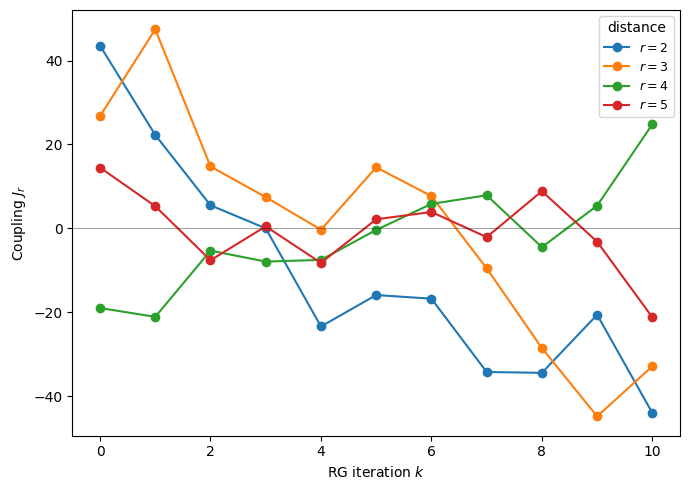

In [128]:
D0 = required_initial_max_distance(max_dist_final=20, n_steps=10)
print(D0)
flow = generate_rg_flow(
    J0=1/0.01,
    a=1.2,
    D=D0,
    n_steps=10,
    p=0.64,
    r_frac=0.4,
    seed=26
)
plot_rg_flow(flow, distances_to_plot=[2, 3, 4, 5,])

## Sink Classification

In [46]:
classify_sink(
    flow,
    track_r=(2,),
    eval_step=None,
    thr_dis=1e-2,
    thr_ord=1e2,
)

('disorder', {'eval_step': 10, 'vals': array([0.00315724])})

## Phase Diagram

Scanning (p, T) phase diagram at a=1.2, r_frac=0.4
  grid: |p|=26 x |T|=26 = 676 points


  disorder:     569
  ferro:        59
  antiferro:    3
  spinglass:    0
  undetermined: 45


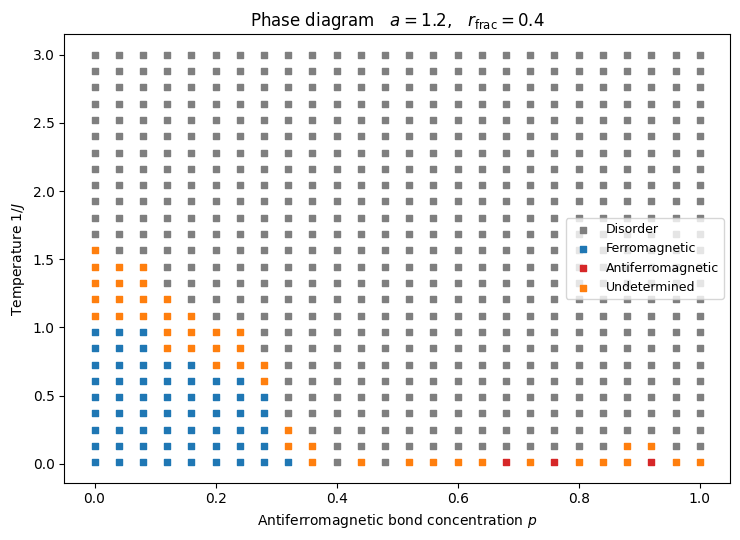

(<Figure size 750x550 with 1 Axes>,
 <Axes: title={'center': 'Phase diagram   $a=1.2$,   $r_{\\rm frac}=0.4$'}, xlabel='Antiferromagnetic bond concentration $p$', ylabel='Temperature $1/J$'>)

In [129]:
# ----------------------------
# Use case: build a (p, T) phase diagram at fixed (a, r_frac)
# ----------------------------

# ---- parameters ----
a               = 1.2     # interaction-range exponent
r_frac          = 0.4     # fraction of zero (missing) bonds
p_values        = np.linspace(0.0, 1.0, 26)
T_values        = np.linspace(0.01, 3.0, 26)
max_dist_final  = 20
n_steps_total   = 10
track_r         = (2,)
thr_dis         = 1e-2
thr_ord         = 1e2

seed            = 12

print(f"Scanning (p, T) phase diagram at a={a}, r_frac={r_frac}")
print(f"  grid: |p|={len(p_values)} x |T|={len(T_values)} = "
        f"{len(p_values)*len(T_values)} points")

dis_pts, fer_pts, af_pts, sg_pts, und_pts = scan_phase_sinks_p_T(
    p_values=p_values,
    T_values=T_values,
    a=a,
    r_frac=r_frac,
    max_dist_final=max_dist_final,
    n_steps_total=n_steps_total,
    track_r=track_r,
    eval_step=None,
    seed=seed,
    thr_dis=thr_dis,
    thr_ord=thr_ord,
    progress="tqdm",   # or "text" for plain prints, or None for silent
)

print(f"  disorder:     {len(dis_pts)}")
print(f"  ferro:        {len(fer_pts)}")
print(f"  antiferro:    {len(af_pts)}")
print(f"  spinglass:    {len(sg_pts)}")
print(f"  undetermined: {len(und_pts)}")

plot_phase_points_p_T(
    disorder_points=dis_pts,
    ferro_points=fer_pts,
    antiferro_points=af_pts,
    spinglass_points=sg_pts,
    undetermined_points=und_pts,
    a=a, r_frac=r_frac,
)

In [119]:
af_pts, sg_pts, und_pts

(array([[0.64, 0.01]]),
 array([], shape=(0, 2), dtype=float64),
 array([[0.    , 1.3256],
        [0.    , 1.4452],
        [0.    , 1.5648],
        [0.    , 1.6844],
        [0.    , 1.804 ],
        [0.04  , 1.3256],
        [0.04  , 1.4452],
        [0.04  , 1.5648],
        [0.04  , 1.6844],
        [0.08  , 1.206 ],
        [0.08  , 1.3256],
        [0.08  , 1.4452],
        [0.08  , 1.5648],
        [0.08  , 1.6844],
        [0.12  , 1.206 ],
        [0.12  , 1.3256],
        [0.12  , 1.4452],
        [0.12  , 1.5648],
        [0.2   , 0.01  ],
        [0.24  , 0.01  ],
        [0.32  , 0.01  ],
        [0.36  , 0.01  ],
        [0.4   , 0.01  ],
        [0.44  , 0.01  ],
        [0.48  , 0.01  ],
        [0.52  , 0.01  ],
        [0.56  , 0.01  ],
        [0.56  , 0.1296],
        [0.6   , 0.01  ],
        [0.6   , 0.1296],
        [0.64  , 0.1296],
        [0.68  , 0.01  ],
        [0.68  , 0.1296],
        [0.72  , 0.01  ],
        [0.76  , 0.01  ],
        [0.8   , 0.01  ],

## Critical Line

In [72]:
def find_Jc_dilute_signed_classify(
    a,
    p,
    r_frac,
    seed=12345,
    Jlow=1e-2,
    Jhigh=1e2,
    max_steps=6,
    max_dist_final=9,
    track_r=(2, 3, 4, 5),
    eval_step=-1,
    tol=1e-5,
    thr_dis=1e-2,
    thr_ord=1e2,
    ordered_phases=("ferro", "antiferro", "spinglass"),
    max_expand=20,
):
    """
    Critical J0 using classify_sink instead of single-coupling growth.

    Uses your existing dilute signed zero-bond RG implementation:
        build_J_dilute_signed
        rg_step
        classify_sink
        required_initial_max_distance
    """

    if not (0 <= a <= 2):
        raise ValueError("a must be in [0, 2].")
    if not (0 <= p <= 1):
        raise ValueError("p must be in [0, 1].")
    if not (0 <= r_frac <= 1):
        raise ValueError("r_frac must be in [0, 1].")

    def phase_at(J0):
        D0 = required_initial_max_distance(max_dist_final, max_steps)

        J = build_J_dilute_signed(
            J0=J0,
            a=a,
            D=D0,
            p=p,
            r_frac=r_frac,
            seed=seed,
        )

        flow = [J.copy()]

        for _ in range(max_steps):
            J = rg_step(J)
            flow.append(J.copy())

        phase, info = classify_sink(
            flow,
            track_r=track_r,
            eval_step=eval_step,
            thr_dis=thr_dis,
            thr_ord=thr_ord,
        )

        return phase, info

    def grows(J0):
        phase, _ = phase_at(J0)

        if phase in ordered_phases:
            return True

        if phase == "disorder":
            return False

        # fallback for undetermined flows:
        # compare final tracked norm to initial tracked norm
        D0 = required_initial_max_distance(max_dist_final, max_steps)

        J = build_J_dilute_signed(
            J0=J0,
            a=a,
            D=D0,
            p=p,
            r_frac=r_frac,
            seed=seed,
        )

        initial_vals = []
        for rr in track_r:
            if rr <= len(J) - 1:
                initial_vals.append(J[rr])
        initial_norm = np.linalg.norm(initial_vals)

        for _ in range(max_steps):
            J = rg_step(J)

        final_vals = []
        for rr in track_r:
            if rr <= len(J) - 1:
                final_vals.append(J[rr])

        final_norm = np.linalg.norm(final_vals) if len(final_vals) else 0.0

        return final_norm > initial_norm

    low_grows = grows(Jlow)
    high_grows = grows(Jhigh)

    # Expand bracket if needed
    n_expand = 0

    while low_grows and n_expand < max_expand:
        Jhigh = Jlow
        Jlow *= 0.5
        low_grows = grows(Jlow)
        high_grows = grows(Jhigh)
        n_expand += 1

    while (not high_grows) and n_expand < max_expand:
        Jlow = Jhigh
        Jhigh *= 2.0
        low_grows = grows(Jlow)
        high_grows = grows(Jhigh)
        n_expand += 1

    if low_grows and high_grows:
        return np.nan, {
            "reason": "both_bounds_ordered",
            "Jlow": Jlow,
            "Jhigh": Jhigh,
        }

    if (not low_grows) and (not high_grows):
        return np.nan, {
            "reason": "both_bounds_disordered",
            "Jlow": Jlow,
            "Jhigh": Jhigh,
        }

    # Bisection
    while (Jhigh - Jlow) > tol:
        Jmid = 0.5 * (Jlow + Jhigh)

        if grows(Jmid):
            Jhigh = Jmid
        else:
            Jlow = Jmid

    Jc = 0.5 * (Jlow + Jhigh)

    phase_c, info_c = phase_at(Jc)

    return Jc, {
        "reason": "converged",
        "Tc": 1.0 / Jc,
        "Jlow": Jlow,
        "Jhigh": Jhigh,
        "phase_at_Jc": phase_c,
        "info_at_Jc": info_c,
    }

In [74]:
Jc, info = find_Jc_dilute_signed_classify(
    a=0.8,
    p=0.0,
    r_frac=0.0,
    seed=12345,
    max_steps=6,
    max_dist_final=9,
    track_r=(2, 3, 4, 5),
    thr_dis=1e-2,
    thr_ord=1e2,
)

Tc = 1.0 / Jc
print(Jc, Tc, info)

0.018883183896541596 52.9571710723607 {'reason': 'converged', 'Tc': 52.9571710723607, 'Jlow': 0.01888020396232605, 'Jhigh': 0.01888616383075714, 'phase_at_Jc': 'undetermined', 'info_at_Jc': {'eval_step': -1, 'vals': array([0.01000116, 0.00998383, 0.00479488, 0.00479345])}}


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
a_vals = np.linspace(0.8, 2.0, 20)

# Fixed parameters
p = 0.0
r_frac = 0.0

# Storage
Jc_vals = []
Tc_vals = []
status = []

for i, a in enumerate(a_vals):
    print(f"[{i+1}/{len(a_vals)}] a = {a:.3f}")

    Jc, info = find_Jc_dilute_signed_classify(
        a=a,
        p=p,
        r_frac=r_frac,
        seed=12345,

        max_steps=6,
        max_dist_final=9,

        track_r=(2, 3, 4, 5),
        thr_dis=1e-2,
        thr_ord=1e2,

        Jlow=1e-2,
        Jhigh=1e2,
        tol=1e-5,
    )

    Jc_vals.append(Jc)

    if np.isfinite(Jc) and Jc > 0:
        Tc_vals.append(1.0 / Jc)
    else:
        Tc_vals.append(np.nan)

    status.append(info["reason"])


Jc_vals = np.array(Jc_vals)
Tc_vals = np.array(Tc_vals)

[1/20] a = 0.800
[2/20] a = 0.863
[3/20] a = 0.926
[4/20] a = 0.989
[5/20] a = 1.053
[6/20] a = 1.116
[7/20] a = 1.179
[8/20] a = 1.242
[9/20] a = 1.305
[10/20] a = 1.368
[11/20] a = 1.432
[12/20] a = 1.495
[13/20] a = 1.558
[14/20] a = 1.621
[15/20] a = 1.684
[16/20] a = 1.747
[17/20] a = 1.811
[18/20] a = 1.874
[19/20] a = 1.937
[20/20] a = 2.000


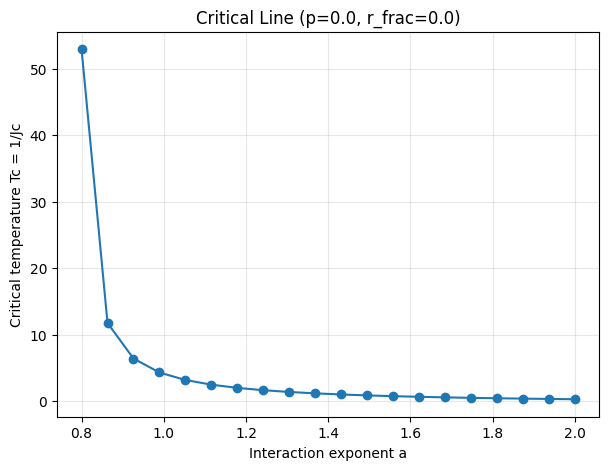

In [76]:
plt.figure(figsize=(7,5))
plt.plot(a_vals, Tc_vals, marker='o')

plt.xlabel("Interaction exponent a")
plt.ylabel("Critical temperature Tc = 1/Jc")
plt.title(f"Critical Line (p={p}, r_frac={r_frac})")

plt.grid(alpha=0.3)
plt.show()

### Seed Averaging

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# ---- parameter grid ----
a_vals = np.linspace(0.8, 2.0, 20)

# fixed parameters
p = 0.1
r_frac = 0.0

# seeds for averaging
n_seeds = 3
seeds = np.arange(n_seeds) + 12345

# storage
Jc_mean = np.zeros_like(a_vals)
Jc_std  = np.zeros_like(a_vals)
Tc_mean = np.zeros_like(a_vals)
Tc_std  = np.zeros_like(a_vals)

# ---- main loop ----
for i, a in enumerate(a_vals):

    print(f"[{i+1}/{len(a_vals)}] a = {a:.3f}")

    Jc_samples = []

    for seed in seeds:

        Jc, info = find_Jc_dilute_signed_classify(
            a=a,
            p=p,
            r_frac=r_frac,
            seed=int(seed),

            max_steps=6,
            max_dist_final=9,

            track_r=(2, 3, 4, 5),
            thr_dis=1e-2,
            thr_ord=1e2,

            Jlow=1e-2,
            Jhigh=1e2,
            tol=1e-5,
        )

        if np.isfinite(Jc) and Jc > 0:
            Jc_samples.append(Jc)

    Jc_samples = np.array(Jc_samples, dtype=float)

    if len(Jc_samples) > 0:
        Jc_mean[i] = np.mean(Jc_samples)
        Jc_std[i]  = np.std(Jc_samples)

        Tc_vals = 1.0 / Jc_samples
        Tc_mean[i] = np.mean(Tc_vals)
        Tc_std[i]  = np.std(Tc_vals)

    else:
        Jc_mean[i] = np.nan
        Jc_std[i]  = np.nan
        Tc_mean[i] = np.nan
        Tc_std[i]  = np.nan

[1/20] a = 0.800
[2/20] a = 0.863
[3/20] a = 0.926
[4/20] a = 0.989
[5/20] a = 1.053
[6/20] a = 1.116
[7/20] a = 1.179
[8/20] a = 1.242
[9/20] a = 1.305
[10/20] a = 1.368
[11/20] a = 1.432
[12/20] a = 1.495
[13/20] a = 1.558
[14/20] a = 1.621
[15/20] a = 1.684
[16/20] a = 1.747
[17/20] a = 1.811
[18/20] a = 1.874
[19/20] a = 1.937
[20/20] a = 2.000


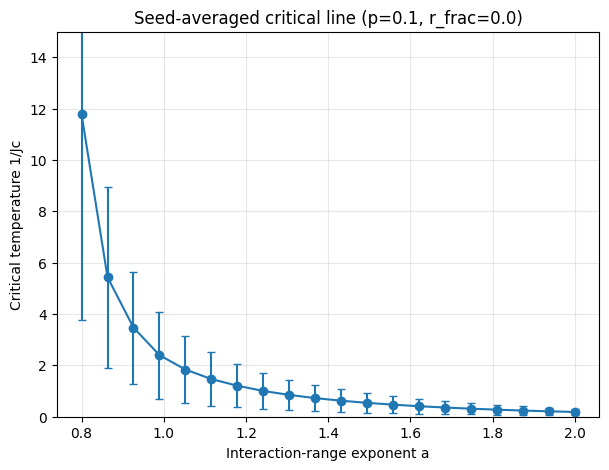

In [133]:
plt.figure(figsize=(7,5))

mask = np.isfinite(Tc_mean)

plt.errorbar(
    a_vals[mask],
    Tc_mean[mask],
    yerr=Tc_std[mask],
    fmt='o-',
    capsize=3,
)

plt.xlabel("Interaction-range exponent a")
plt.ylabel("Critical temperature 1/Jc")
plt.title(f"Seed-averaged critical line (p={p}, r_frac={r_frac})")
plt.ylim(0, 15)
plt.grid(alpha=0.3)
plt.show()

#### Multiple lines

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# ---- a range ----
a_vals = np.linspace(0.75, 2.0, 30)

# ---- fixed parameter sets: each gives one critical curve ----
parameter_sets = [
    #{"p": 0.0, "r_frac": 0.0, "label": "p=0.0, r=0.0"},
    {"p": 0.0, "r_frac": 0.1, "label": "p=0.0, r=0.1"},
    #{"p": 0.0, "r_frac": 0.2, "label": "p=0.0, r=0.3"},
    #{"p": 0.0, "r_frac": 0.3, "label": "p=0.0, r=0.5"},
    #{"p": 0.0, "r_frac": 0.4, "label": "p=0.0, r=0.4"},
]

# ---- seed averaging ----
n_seeds = 12
seeds = np.arange(n_seeds) + 12345

results = {}

for pars in parameter_sets:

    p = pars["p"]
    r_frac = pars["r_frac"]
    label = pars["label"]

    print(f"\n=== Computing curve: {label} ===")

    Jc_mean = np.full_like(a_vals, np.nan, dtype=float)
    Jc_std  = np.full_like(a_vals, np.nan, dtype=float)
    Tc_mean = np.full_like(a_vals, np.nan, dtype=float)
    Tc_std  = np.full_like(a_vals, np.nan, dtype=float)
    n_valid = np.zeros_like(a_vals, dtype=int)

    for i, a in enumerate(a_vals):

        print(f"[{i+1}/{len(a_vals)}] a = {a:.3f}")

        Jc_samples = []

        for seed in seeds:

            Jc, info = find_Jc_dilute_signed_classify(
                a=a,
                p=p,
                r_frac=r_frac,
                seed=int(seed),

                max_steps=6,
                max_dist_final=9,

                track_r=(2, 3, 4, 5),
                thr_dis=1e-2,
                thr_ord=1e2,

                Jlow=1e-2,
                Jhigh=1e2,
                tol=1e-5,
            )

            if np.isfinite(Jc) and Jc > 0:
                Jc_samples.append(Jc)

        Jc_samples = np.array(Jc_samples, dtype=float)
        n_valid[i] = len(Jc_samples)

        if len(Jc_samples) > 0:
            Jc_mean[i] = np.mean(Jc_samples)
            Jc_std[i]  = np.std(Jc_samples)

            Tc_samples = 1.0 / Jc_samples
            Tc_mean[i] = np.mean(Tc_samples)
            Tc_std[i]  = np.std(Tc_samples)

    results[label] = {
        "p": p,
        "r_frac": r_frac,
        "a_vals": a_vals.copy(),
        "Jc_mean": Jc_mean,
        "Jc_std": Jc_std,
        "Tc_mean": Tc_mean,
        "Tc_std": Tc_std,
        "n_valid": n_valid,
    }


=== Computing curve: p=0.0, r=0.1 ===
[1/30] a = 0.750
[2/30] a = 0.793
[3/30] a = 0.836
[4/30] a = 0.879
[5/30] a = 0.922
[6/30] a = 0.966
[7/30] a = 1.009
[8/30] a = 1.052
[9/30] a = 1.095
[10/30] a = 1.138
[11/30] a = 1.181
[12/30] a = 1.224
[13/30] a = 1.267
[14/30] a = 1.310
[15/30] a = 1.353
[16/30] a = 1.397
[17/30] a = 1.440
[18/30] a = 1.483
[19/30] a = 1.526
[20/30] a = 1.569
[21/30] a = 1.612
[22/30] a = 1.655
[23/30] a = 1.698
[24/30] a = 1.741
[25/30] a = 1.784
[26/30] a = 1.828
[27/30] a = 1.871
[28/30] a = 1.914
[29/30] a = 1.957
[30/30] a = 2.000


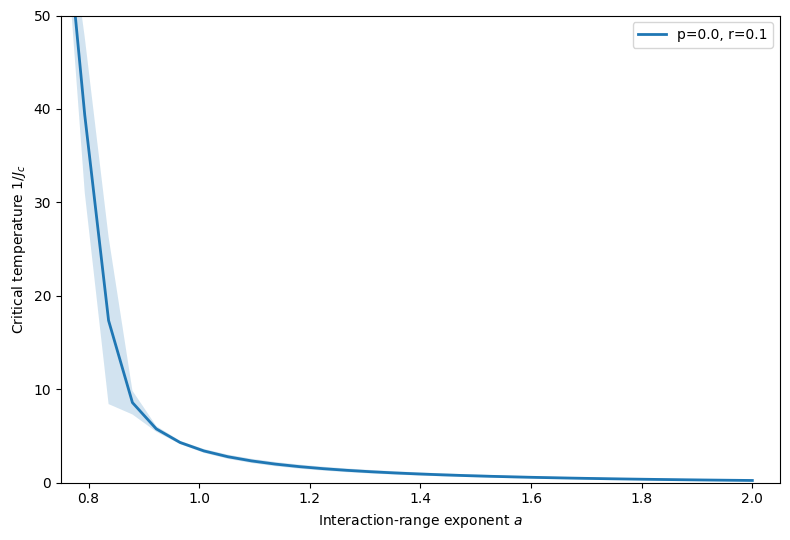

In [138]:
plt.figure(figsize=(8, 5.5))

for label, res in results.items():

    a = res["a_vals"]
    Tc = res["Tc_mean"]
    Tc_err = res["Tc_std"]

    mask = np.isfinite(Tc)

    a_plot = a[mask]
    Tc_plot = Tc[mask]
    err_plot = Tc_err[mask]

    # mean curve
    plt.plot(a_plot, Tc_plot, linewidth=2, label=label)

    # continuous uncertainty band
    plt.fill_between(
        a_plot,
        Tc_plot - err_plot,
        Tc_plot + err_plot,
        alpha=0.2
    )
plt.xlim(0.75, 2.05)
plt.ylim(0, 50)
plt.xlabel(r"Interaction-range exponent $a$")
plt.ylabel(r"Critical temperature $1/J_c$")
#plt.title("Critical lines with continuous uncertainty bands")

plt.grid(alpha=0.0)
plt.legend()
plt.tight_layout()
plt.show()